# DINOv3 SAT sur HEALPix — réglage sur une seule date

Ce notebook fait tourner `GetDINOV3SAT` sur **une date** du store Sentinel-2
HEALPix et donne de quoi comprendre ce que fait le réseau avant de faire
confiance à une classification.

Le k-means tourne **sur les coordonnées UMAP**, pas sur les 1024 dimensions de
DINOv3. Raison : k-means cherche des groupes sphériques de variance comparable,
ce que les embeddings bruts ne forment pas — ils vivent sur une variété courbe où
les distances euclidiennes ne veulent pas dire grand-chose. UMAP déplie cette
variété et sépare les paquets, ce que k-means sait alors découper.

Le prix à en connaître : UMAP déforme les distances globales, la taille et
l'écartement des groupes sur le tracé ne sont pas interprétables, et le résultat
dépend de `n_neighbors`, `min_dist` et de la graine aléatoire. Deux réglages
différents donnent deux partitions différentes, toutes deux « valables ». D'où
§12, qui compare la partition UMAP à celle obtenue directement sur DINOv3 et à
un k-means sur la couleur seule.

L'ordre des cellules évite de recalculer ce qui coûte cher :

| étape | coût | cellule |
|---|---|---|
| lecture de la date | ~1 min la 1re fois, puis cache disque | §2 |
| découpage en tuiles (+ comparaison des géométries) | secondes | §3 |
| passage dans DINOv3 | 10 s – 2 min | §4 |
| effet tuile + normalisation | instantané | **§5 — à rejouer si on change `TOKEN_NORM`** |
| PCA de contrôle | instantané | §6 |
| **UMAP** | 10 s – 1 min | **§7 — à rejouer si on change `n_neighbors`** |
| **k-means** | instantané | **§8 — à rejouer pour régler `K`** |
| cartes, inspection | secondes | §9 – §12 |

## 1. Paramètres

In [1]:
import os, sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))          # pour importer les modules voisins
sys.path.insert(0, str(Path.cwd().parent))   # pour importer healpix_analyse en dev

from healpix_analyse.dino import (
    GetDINOV3SAT, healpix_gsd_m, load_dinov3_sat, nested_to_tiles, set_ellipsoid,
    tangent_tiles,
)
from dino_umap_sentinel2 import FakeDino, categorical_cmap
from g4e_source import G4E_L2A, G4E_PRODUCTS, RGB, ProductSeries, TimeSeriesStore

# --------------------------------------------------------------------------
# À RÉGLER
# --------------------------------------------------------------------------
# Donnees : bucket public GRID4EARTH (docs/bucket-layout.md du projet).
# https://data.grid4earth.eu sert le repertoire `public` du bucket OVH, et le
# niveau HEALPix est un GROUPE du produit, pas une dimension :
#     legacy/sentinel-2-l2a/<PRODUIT>.zarr/measurements/reflectance/<niveau>
COLLECTION = G4E_L2A                 # ou .../legacy/sentinel-2-l1c
PRODUCTS   = list(G4E_PRODUCTS)      # un produit = une acquisition
DATA_LEVEL = 20                      # le groupe a lire (le produit publie 17, 19, 20)
SOURCE     = "g4e"                   # "g4e", ou l'URL d'un store a dimension time

CACHE   = os.path.expanduser("~/s2_cache")   # None pour ne rien mettre en cache
WEIGHTS = os.path.expanduser("~/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth")

TIME_INDEX   = 0      # le produit etudie (liste imprimee en §2)
TILE_LEVELS  = 7      # côté des tuiles DINO = 2**TILE_LEVELS px (8 -> 256 px)
AUTO_TILE    = True   # si TILE_LEVELS ne donne aucune tuile complète, en choisir un qui marche
MIN_COVERAGE = 1.0    # 1.0 = uniquement les tuiles parent COMPLÈTES (aucun NaN)

# Geometrie (§3) : "tangent" = plan tangent local (formes correctes),
#                  "nested"  = repliage d'indices (exact mais deforme)
PROJECTION  = "tangent"   # "tangent" | "nested" | "percell"
OVER_SAMPLE = 1       # fenetre glissante : 2 -> tokens 2x plus denses, cout x4
GSD_M       = None    # pas au sol de la grille tangente (None = natif HEALPix)
CONTEXT_PX  = None    # fenetre du mode "percell" : None = empreinte de la cellule
                      # (1 token par cellule, meme cout que le mode tuile) ; 48 ou 80
                      # donnent du contexte au reseau pour 9x ou 25x plus de tokens

# Normalisation des tokens (§5) : "none" | "tile" | "pc" | "tile+pc"
TOKEN_NORM = "tile"   # "tile" retire la moyenne de chaque tuile — voir §5
N_DROP_PC  = 1        # composantes principales retirées si TOKEN_NORM contient "pc"

# UMAP (§7)
UMAP_DIM       = 2    # dimensions où le k-means travaille. 2 = ce qu'on voit ;
                      # 5 à 10 sépare souvent mieux, les 2 premières servant à l'affichage
UMAP_NEIGHBORS = 30   # petit (10) = détail local ; grand (100) = structure globale
UMAP_MIN_DIST  = 0.0  # 0.0 tasse les groupes, ce qui aide le k-means

# k-means (§8)
K = 20

FAKE = False          # True = réseau aléatoire, pour tester la mécanique sans poids
# --------------------------------------------------------------------------

print("bandes RGB utilisées :", RGB)

bandes RGB utilisées : ('b04', 'b03', 'b02')


## 2. Lecture d'une acquisition

Chaque produit est un store zarr séparé, et le niveau HEALPix y est un **groupe**
(`measurements/reflectance/<niveau>`) — il n'y a donc pas de dimension `time` :
une série temporelle est une liste de produits. La première exécution télécharge
le produit ; avec `CACHE`, les suivantes le relisent sur disque.

In [2]:
if SOURCE == "g4e":
    src = ProductSeries(PRODUCTS, level=DATA_LEVEL, base=COLLECTION, bands=RGB)
else:
    src = TimeSeriesStore(SOURCE, bands=RGB)

level, cell_id, dates = src.level, src.cell_id, src.dates

# L'ellipsoide declare par le store gouverne toute la geometrie (centres de
# cellules, plans tangents) : les produits EOPF sont en WGS84, pas sur la sphere.
set_ellipsoid(getattr(src, "ellipsoid", "sphere"))
print("ellipsoide :", getattr(src, "ellipsoid", "sphere"))
print(f"niveau HEALPix {level}, {cell_id.size} cellules, {len(dates)} acquisitions")
print("dates :", ", ".join(f"{i}:{d}" for i, d in enumerate(dates[:12])))

t0 = time.time()
rgb = src.rgb(TIME_INDEX, cache=CACHE)             # [N, 3] réflectances dans [0, 1]
print(f"produit {TIME_INDEX} = {dates[TIME_INDEX]} lu en {time.time()-t0:.0f}s ; "
      f"NaN : {100*np.isnan(rgb).any(1).mean():.1f}% des cellules")
rgb*=1E4

2 products, level 20, 4456448 cells, bands ['b02', 'b03', 'b04', 'b08'], ellipsoid wgs84
ellipsoide : wgs84
niveau HEALPix 20, 4456448 cellules, 2 acquisitions
dates : 0:2025-05-22, 1:2025-05-27
produit 0 = 2025-05-22 lu en 0s ; NaN : 0.0% des cellules


## 3. Découpage en tuiles — *ce que le réseau va vraiment voir*

C'est l'étape à regarder en premier quand un résultat semble incompréhensible.
`nested_to_tiles` replie chaque cellule de `parent_level` en une image carrée
exacte (aucun rééchantillonnage). Avec `fill="nan"` on voit les trous tels quels.

Rappel d'orientation : le nord d'une face HEALPix pointe vers le **coin
haut-droit** de l'image, pas vers le haut. Une image qui « penche » de 45° est
normale.

  TILE_LEVELS  cote (px)  tuiles  completes
            4         16   17408      17408
            5         32    4352       4352
            6         64    1088       1088
            7        128     272        272
            8        256      68         68
            9        512      17         17
           10       1024       7          2
  (geometrie nested ; en tangent les tuiles de bord perdent un peu de couverture)
272 tuiles de 160 px au niveau 13 (tangent) ; 179 à couverture >= 1.0
  en mode tangent le carré déborde du losange nested : les tuiles de bord du domaine n'atteignent jamais 1.0, celles de l'intérieur si, en puisant dans les cellules voisines
couverture : min 0.708  médiane 1.000  max 1.000


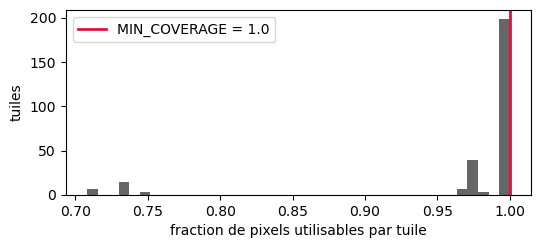

In [3]:
# Une tuile de 2**TILE_LEVELS px couvre 4**TILE_LEVELS cellules ; si la scene
# est plus petite que ca, aucune tuile n'est complete et tout le reste du
# notebook part en vrille. On mesure d'abord, on choisit ensuite.
_cid = np.asarray(cell_id).reshape(-1)
_fin = np.isfinite(np.asarray(rgb, dtype=float))
_usable = (_fin.all(axis=1) if _fin.ndim > 1 else _fin).reshape(-1)
if _usable.size != _cid.size:
    raise ValueError(
        f"rgb {np.shape(rgb)} et cell_id {np.shape(cell_id)} ne correspondent pas "
        f"({_usable.size} valeurs contre {_cid.size} identifiants).\n"
        "Presque toujours : les cellules de §1/§2 ont ete executees dans le desordre, "
        "ou DATA_LEVEL a change sans relire les donnees. Kernel > Restart & Run All.")

print("  TILE_LEVELS  cote (px)  tuiles  completes")
_scan = {}
for _tl in range(4, 11):
    _pl = level - _tl
    if _pl < 0:
        break
    # comptage entier : combien de cellules utilisables par tuile parent.  Pas
    # de construction d'image ici, sinon le scan coute plus cher que le calcul.
    # (.reshape(-1) : selon la version de numpy, return_inverse rend (N,) ou (N, 1))
    _par = _cid >> np.int64(2 * _tl)
    _uq, _iv = np.unique(_par, return_inverse=True)
    _iv = np.asarray(_iv).reshape(-1)
    _got = np.bincount(_iv[_usable], minlength=_uq.size)
    _scan[_tl] = (int(_uq.size), int((_got >= MIN_COVERAGE * 4 ** _tl).sum()))
    print(f"  {_tl:>11}  {2**_tl:>9}  {_scan[_tl][0]:>6}  {_scan[_tl][1]:>9}")
print("  (geometrie nested ; en tangent les tuiles de bord perdent un peu de couverture)")

# Ce qu'il faut atteindre depend du mode :
#  - tuile (tangent/nested) : des tuiles COMPLETES, chacune donnant un embedding ;
#  - percell : une cellule de sortie par tuile, il en faut assez pour classer.
if PROJECTION == "percell":
    _need = max(50, 4 * K)
    _score = {tl: n_tiles for tl, (n_tiles, _) in _scan.items()}
    _why = f"moins de {_need} cellules de sortie"
else:
    _need = 8
    _score = {tl: n_full for tl, (_, n_full) in _scan.items()}
    _why = "aucune tuile complete"

if AUTO_TILE and _score.get(TILE_LEVELS, 0) < max(1, _need // 8):
    _ok = [tl for tl, v in _score.items() if v >= _need] or \
          [tl for tl, v in _score.items() if v >= 1]
    if _ok and max(_ok) != TILE_LEVELS:
        print(f"\n  ATTENTION : TILE_LEVELS = {TILE_LEVELS} donne {_why} sur cette "
              f"scene ; on passe a {max(_ok)}.")
        print("  Mets AUTO_TILE = False pour garder ton reglage tel quel.")
        TILE_LEVELS = max(_ok)

parent_level = level - TILE_LEVELS

# les deux geometries, pour pouvoir les comparer juste en dessous
tiles_nest, ids_nest, _, cov_nest = nested_to_tiles(
    rgb, cell_id, level, parent_level, fill="nan")
tiles_tan, ids_tan, _, cov_tan, tan_lon, tan_lat = tangent_tiles(
    rgb, cell_id, level, parent_level, gsd_m=GSD_M, fill="nan")

if PROJECTION == "nested":
    tiles, parent_ids, coverage = tiles_nest, ids_nest, cov_nest
else:            # "tangent" et "percell" partagent la geometrie du plan tangent
    tiles, parent_ids, coverage = tiles_tan, ids_tan, cov_tan
if PROJECTION == "percell":
    print("mode percell : ces tuiles ne servent qu'a l'affichage ; le calcul utilisera "
          f"une fenetre propre a chaque cellule de niveau {parent_level}")

keep = coverage >= MIN_COVERAGE
print(f"{tiles.shape[0]} tuiles de {tiles.shape[-1]} px au niveau {parent_level} "
      f"({PROJECTION}) ; {keep.sum()} à couverture >= {MIN_COVERAGE}")

if keep.sum() == 0:
    print("\n  Aucune tuile ne passe le seuil (tableau ci-dessus) : on garde les "
          "meilleures pour que la suite tourne, mais les images sont incompletes.")
    keep = coverage >= np.quantile(coverage, 0.5)
if PROJECTION == "tangent":
    print("  en mode tangent le carré déborde du losange nested : les tuiles de bord "
          "du domaine n'atteignent jamais 1.0, celles de l'intérieur si, en puisant "
          "dans les cellules voisines")
print("couverture : min %.3f  médiane %.3f  max %.3f"
      % (coverage.min(), np.median(coverage), coverage.max()))

fig, ax = plt.subplots(figsize=(6, 2.4))
ax.hist(coverage, bins=40, color="0.4")
ax.axvline(MIN_COVERAGE, color="crimson", lw=2, label=f"MIN_COVERAGE = {MIN_COVERAGE}")
ax.set_xlabel("fraction de pixels utilisables par tuile"); ax.set_ylabel("tuiles")
ax.legend(); plt.show()

(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)
(240, 160, 3)


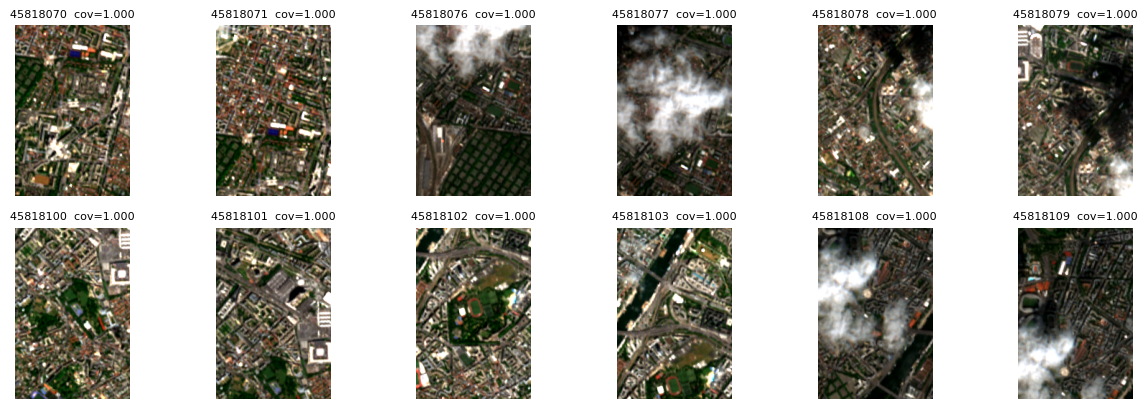

In [17]:
def show_tiles(imgs, titles=None, ncol=6, size=2.1, cmap=None, **kw):
    """Planche de vignettes."""
    n = len(imgs)
    if n == 0:
        print("(rien a afficher : la selection est vide)")
        return None
    ncol = min(ncol, n)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(size * ncol, size * nrow), squeeze=False)
    for i, a in enumerate(axes.ravel()):
        a.set_axis_off()
        if i >= n:
            continue
        print(imgs[i].shape)
        a.imshow(imgs[i], cmap=cmap, **kw)
        if titles is not None:
            a.set_title(titles[i], fontsize=8)
    fig.tight_layout()
    return fig

def to_rgb(tile, p_low=2, p_high=98):
    """[3, S, S] -> image affichable, étirée sur des percentiles (NaN en noir)."""
    img = np.transpose(tile, (1, 2, 0))
    lo, hi = np.nanpercentile(img, [p_low, p_high])
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0, 1)

idx = np.where(keep)[0][:12]
show_tiles([to_rgb(tiles[i]) for i in idx],
           [f"{parent_ids[i]}  cov={coverage[i]:.3f}" for i in idx])
plt.show()

### 3b. Pourquoi le plan tangent

Les cellules HEALPix ont la meme **aire** mais pas la meme **forme** : dans une
face, les deux axes nested ne sont ni orthogonaux ni de meme longueur, et la
deformation croit avec la latitude. A 52 degres N et au niveau 19, les deux pas
mesurent 10,6 m et 16,7 m avec un angle de 60,5 degres : l'image « carree » du
mode `nested` est en fait un parallelogramme etire d'un facteur 2 et cisaille de
30 degres. DINOv3, entraine sur de l'imagerie projetee normalement, n'a aucune
raison d'y reconnaitre les memes objets.

Le mode `tangent` reechantillonne chaque tuile sur un plan tangent local
nord-en-haut a pas constant au sol. On y perd l'exactitude du repliage
(c'est une interpolation) et l'alignement exact des tokens sur des cellules
HEALPix, on y gagne des formes justes. La cellule suivante montre l'ecart sur
la meme zone.

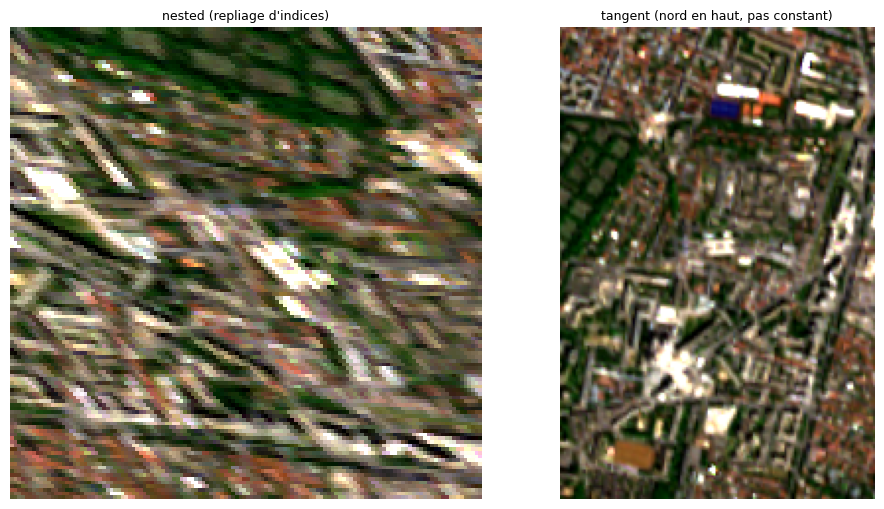

pas nested au centre de la tuile : x = 5.31 m, y = 8.87 m (rapport 1.67)
pas de la grille tangente : 6.22 m


In [5]:
j = int(np.argmax(coverage))
cell_ref = parent_ids[j]
a = tiles_nest[np.searchsorted(ids_nest, cell_ref)]
b = tiles_tan[np.searchsorted(ids_tan, cell_ref)]

fig, ax = plt.subplots(1, 2, figsize=(10, 5.2))
ax[0].imshow(to_rgb(a)); ax[0].set_title("nested (repliage d'indices)", fontsize=9)
ax[1].imshow(to_rgb(b)); ax[1].set_title("tangent (nord en haut, pas constant)", fontsize=9)
for x in ax:
    x.set_axis_off()
fig.tight_layout(); plt.show()

# anisotropie locale mesuree : longueur des deux pas nested au centre de la tuile
from healpix_analyse.dino import (EARTH_RADIUS_M, cell_vectors,
                                 nested_to_xy, xy_to_nested)
nside = 2 ** level
p0 = int(cell_ref) << (2 * TILE_LEVELS)
face = p0 // (nside * nside)
xx, yy = nested_to_xy(np.array([p0 - face * nside * nside]))
def _v(dx, dy):
    q = face * nside * nside + int(xy_to_nested(np.array([xx[0] + dx]), np.array([yy[0] + dy]))[0])
    return cell_vectors(level, np.array([q]))[:, 0]
v0 = _v(0, 0)
lx = np.linalg.norm((_v(1, 0) - v0) * EARTH_RADIUS_M)
ly = np.linalg.norm((_v(0, 1) - v0) * EARTH_RADIUS_M)
print(f"pas nested au centre de la tuile : x = {lx:.2f} m, y = {ly:.2f} m "
      f"(rapport {max(lx, ly)/min(lx, ly):.2f})")
print(f"pas de la grille tangente : {healpix_gsd_m(level) if GSD_M is None else GSD_M:.2f} m")

Si ces vignettes ne ressemblent pas à des paysages, inutile d'aller plus loin :
le problème est en amont (bandes, échelle des réflectances, niveau HEALPix).
Augmenter `TILE_LEVELS` si les tuiles sont trop petites pour montrer une
structure.

## 4. Passage dans DINOv3

`return_patches=True` donne un vecteur par cellule de `level - 4`
(un patch de 16 px), c'est ce qui sert à la classification.

In [6]:
model = FakeDino() if FAKE else load_dinov3_sat("dinov3_vitl16", WEIGHTS)

t0 = time.time()
res = GetDINOV3SAT(
    rgb, cell_id, level, parent_level,
    projection=PROJECTION, over_sample=OVER_SAMPLE, gsd_m=GSD_M,
    context_px=CONTEXT_PX,
    model=model, return_patches=True, min_coverage=MIN_COVERAGE,
)
G = int(round(np.sqrt(res.patch_embedding.shape[0] / max(res.cell_id.size, 1))))
E = res.patch_embedding.reshape(res.cell_id.size, G, G, -1)     # [tuile, ligne, colonne, D]

print(f"{res.cell_id.size} tuiles -> {res.patch_embedding.shape} en {time.time()-t0:.0f}s")
print(f"grille de patches : {G}x{G} par tuile, dimension {E.shape[-1]}, "
      f"niveau des patches {res.patch_level}, projection {res.projection}, "
      f"over_sample {res.over_sample}")

# les tuiles gardées, dans le même ordre que res.cell_id
sel = np.searchsorted(parent_ids, res.cell_id)
kept_tiles = tiles[sel]

# vecteurs normalisés L2 ; §5 les renormalise selon TOKEN_NORM
z = res.patch_embedding.astype(np.float32)
z = z / (np.linalg.norm(z, axis=1, keepdims=True) + 1e-8)

# Couleur moyenne de chaque cellule de sortie, calculee sur les donnees elles-memes
# (et non sur la grille de l'image) : valable pour les trois projections.
_shift = 2 * (level - res.patch_level)
_uniq, _inv = np.unique(cell_id >> _shift, return_inverse=True)
_inv = np.asarray(_inv).ravel()      # numpy peut rendre (N, 1)
_acc = np.zeros((_uniq.size, 3)); _cnt = np.zeros((_uniq.size, 3))
_fin = np.isfinite(rgb)
np.add.at(_acc, _inv, np.where(_fin, rgb, 0.0))
np.add.at(_cnt, _inv, _fin)
with np.errstate(invalid="ignore"):
    _mean = np.where(_cnt > 0, _acc / _cnt, np.nan)
_pos = np.clip(np.searchsorted(_uniq, res.patch_cell_id), 0, _uniq.size - 1)
px = np.where((_uniq[_pos] == res.patch_cell_id)[:, None], _mean[_pos], np.nan)  # [cellule, 3]

# --- geometrie : le patch est-il carre au sol, et chaque cellule a-t-elle son
# --- propre token ?
from healpix_analyse.dino import (EARTH_RADIUS_M, cell_vectors, cells_at_lonlat,
                                 cell_centres_lonlat, cell_neighbours,
                                 nested_to_xy, xy_to_nested)
_gsd_used = healpix_gsd_m(level) if GSD_M is None else GSD_M
_pat = 16 * _gsd_used
print(f"patch DINO : {_pat:.1f} m x {_pat:.1f} m au sol (carre, par construction : "
      f"la grille tangente a le meme pas dans les deux directions)")

_ns = 2 ** res.patch_level
_p0 = int(res.patch_cell_id[res.patch_cell_id.size // 2])
_f = _p0 // (_ns * _ns)
_xx, _yy = nested_to_xy(np.array([_p0 - _f * _ns * _ns]))
def _vec(dx, dy):
    q = _f * _ns * _ns + int(xy_to_nested(np.array([_xx[0] + dx]), np.array([_yy[0] + dy]))[0])
    return cell_vectors(res.patch_level, np.array([q]))[:, 0]
_v0 = _vec(0, 0)
_lx = np.linalg.norm((_vec(1, 0) - _v0) * EARTH_RADIUS_M)
_ly = np.linalg.norm((_vec(0, 1) - _v0) * EARTH_RADIUS_M)
_ratio = max(_lx, _ly) / min(_lx, _ly)
print(f"cellule de sortie (niveau {res.patch_level}) : {_lx:.1f} m x {_ly:.1f} m "
      f"(rapport {_ratio:.2f})"
      + (" — meme aire que le patch, mais pas la meme forme" if _ratio > 1.05
         else " — quasi carree a cette latitude"))

if PROJECTION != "percell" and res.patch_embedding.size:
    # combien de cellules recoivent le meme token qu'une voisine ? la grille de
    # tokens est carree, les cellules non : le rapport d'aspect en fixe le taux
    _h = res.patch_embedding @ np.random.default_rng(0).normal(
        size=res.patch_embedding.shape[1])
    _dup = 1.0 - np.unique(np.round(_h, 6)).size / _h.size
    print(f"cellules partageant leur token avec une voisine : {100*_dup:.0f}%")
    if _dup > 0.02:
        print("  (consequence directe du rapport d'aspect ; PROJECTION='percell' "
              "l'annule, ou GSD_M = healpix_gsd_m(level)/1.3 affine la grille)")

# Rasteriseur : une valeur par cellule -> image sur la grille tangente d'une tuile.
# Indispensable maintenant que les tokens sont attaches a des cellules HEALPix :
# un reshape en [G, G] donnerait l'ordre nested (Morton), pas une image.
_order = np.argsort(res.patch_cell_id)
_sid = res.patch_cell_id[_order]

def raster(values, j):
    """`values` [Ncellule, ...] -> image [h, w, ...] sur la grille tangente de la tuile j."""
    t = int(np.searchsorted(ids_tan, res.cell_id[j]))
    ids_img = cells_at_lonlat(res.patch_level, tan_lon[t], tan_lat[t])
    q = np.clip(np.searchsorted(_sid, ids_img), 0, _sid.size - 1)
    hit = _sid[q] == ids_img
    v = np.asarray(values, dtype=float)
    if v.ndim == 1:
        v = v[:, None]                       # toujours [h, w, C] en sortie
    return np.where(hit[..., None], v[_order][q], np.nan)

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


179 tuiles -> (11456, 1024) en 8s
grille de patches : 8x8 par tuile, dimension 1024, niveau des patches 16, projection tangent, over_sample 1
patch DINO : 99.5 m x 99.5 m au sol (carre, par construction : la grille tangente a le meme pas dans les deux directions)
cellule de sortie (niveau 16) : 84.9 m x 142.0 m (rapport 1.67) — meme aire que le patch, mais pas la meme forme
cellules partageant leur token avec une voisine : 9%
  (consequence directe du rapport d'aspect ; PROJECTION='percell' l'annule, ou GSD_M = healpix_gsd_m(level)/1.3 affine la grille)


## 5. Effet tuile — *a regarder avant toute classification*

Symptome typique : sur la carte des groupes, **le contour des tuiles est
visible**, chaque tuile portant une couleur dominante. Ce n'est pas un bug du
decoupage HEALPix, c'est une propriete du ViT : son attention est globale, donc
chaque token « voit » toute la tuile. Si les tuiles different par leur
radiometrie d'ensemble — voile nuageux, ombre de cirrus, angle solaire — cet
ecart global se retrouve dans **tous** les tokens de la tuile et domine la
variance. Le k-means classe alors les tuiles, pas le terrain.

La cellule ci-dessous chiffre le phenomene : la part de variance des tokens
portee par la moyenne de chaque tuile. Au-dela de ~0.5, la classification
mesure surtout a quelle tuile appartient un patch.

Trois remedes, cumulables :

- `TOKEN_NORM = "tile"` — retirer de chaque token la moyenne des tokens de sa
  tuile. Radical et efficace. **Ce qu'on y perd** : les differences reelles
  entre tuiles entieres (une tuile 100 % foret et une tuile 100 % ville
  deviennent comparables), donc la classification devient *relative a chaque
  tuile*. Acceptable si les tuiles sont grandes devant les objets, discutable
  sinon.
- `TOKEN_NORM = "pc"` — retirer les `N_DROP_PC` premieres composantes
  principales globales. Plus doux : la premiere composante capte en general
  l'illumination. Ne supprime pas completement l'effet tuile.
- **Tuiles plus grandes** (`TILE_LEVELS = 10`, soit 1024 px) — moins de
  frontieres, et l'effet devient relativement moins fort.

Le fond du probleme reste la donnee : une date voilee par des nuages fins
produira toujours des embeddings domines par le voile. Choisir une date claire
est le premier remede.

In [7]:
z_raw = z.copy()

if G == 1:
    # mode percell : un token par cellule, donc pas d'effet tuile a mesurer et
    # surtout aucune moyenne de tuile a retirer (cela mettrait tout a zero)
    print("mode percell : une fenetre par cellule, il n'y a pas d'effet tuile")
    if "tile" in TOKEN_NORM:
        print("  TOKEN_NORM 'tile' est ignore ici ; seule la partie 'pc' s'applique")
else:
    Z = z.reshape(res.cell_id.size, G * G, -1)
    tile_mean = Z.mean(axis=1, keepdims=True)
    grand = z.mean(axis=0)
    between = ((tile_mean[:, 0] - grand) ** 2).sum() * (G * G)
    total = ((z - grand) ** 2).sum()
    print(f"part de variance portee par la moyenne des tuiles : {between/total:.3f}")
    print("  (au-dela de 0.5, la classification suit surtout le decoupage en tuiles)")
    if "tile" in TOKEN_NORM:
        z = (Z - tile_mean).reshape(z.shape[0], -1)
if "pc" in TOKEN_NORM:
    from sklearn.decomposition import PCA as _PCA
    pc = _PCA(n_components=N_DROP_PC, random_state=0).fit(z)
    z = z - pc.inverse_transform(pc.transform(z))
z = z / (np.linalg.norm(z, axis=1, keepdims=True) + 1e-8)

if G > 1:
    Zn = z.reshape(res.cell_id.size, G * G, -1)
    b2 = ((Zn.mean(1) - z.mean(0)) ** 2).sum() * (G * G)
    print(f"apres TOKEN_NORM={TOKEN_NORM!r} : {b2/((z - z.mean(0))**2).sum():.3f}")

part de variance portee par la moyenne des tuiles : 0.257
  (au-dela de 0.5, la classification suit surtout le decoupage en tuiles)
apres TOKEN_NORM='tile' : 0.001


## 6. Les features ont-elles un sens ? — PCA des tokens

Le test standard sur DINO : projeter les tokens de patch sur leurs **3 premières
composantes principales** et les afficher en RGB. Si le réseau « voit » quelque
chose, cette image fait apparaître les objets (champs, forêt, routes, eau) sans
aucune supervision. Si elle ressemble à du bruit, le problème vient des
embeddings et ni UMAP ni k-means n'y changeront rien.

variance expliquée par les 3 premières composantes : [0.109 0.063 0.042]


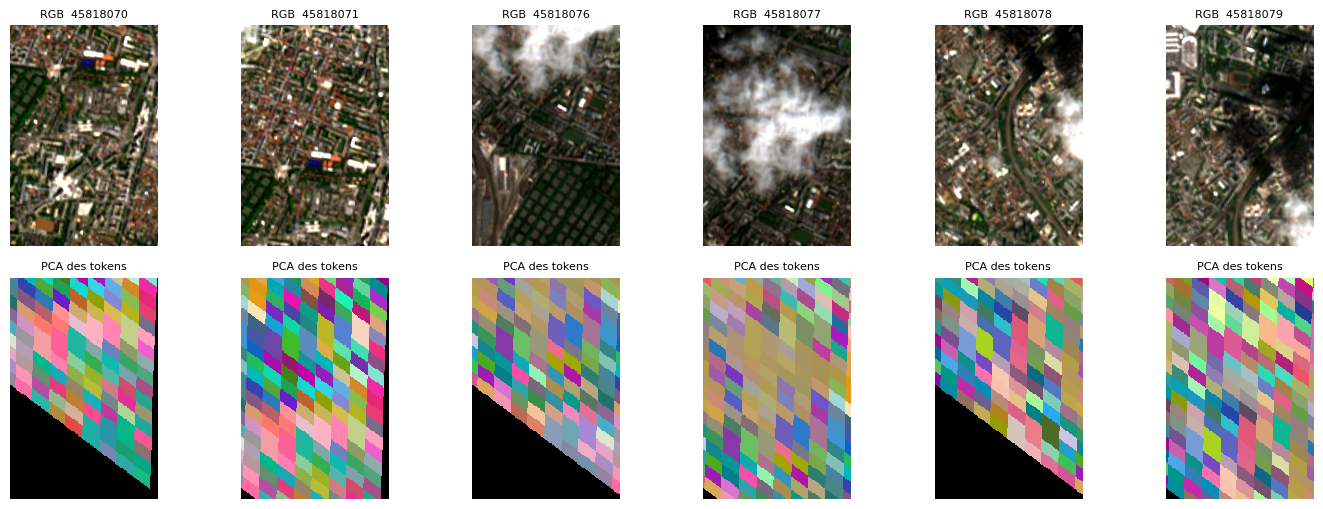

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=0).fit(z)
proj = pca.transform(z)                                   # [cellule, 3]
lo, hi = np.percentile(proj, [2, 98])
proj_n = np.clip((proj - lo) / (hi - lo), 0, 1)
print("variance expliquée par les 3 premières composantes :",
      np.round(pca.explained_variance_ratio_, 3))

n = min(6, res.cell_id.size)
fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.2), squeeze=False)
for j in range(n):
    axes[0, j].imshow(to_rgb(kept_tiles[j])); axes[0, j].set_axis_off()
    axes[0, j].set_title(f"RGB  {res.cell_id[j]}", fontsize=8)
    axes[1, j].imshow(np.nan_to_num(raster(proj_n, j)), interpolation="nearest")
    axes[1, j].set_axis_off(); axes[1, j].set_title("PCA des tokens", fontsize=8)
fig.tight_layout(); plt.show()

## 7. UMAP — **à rejouer si on change `UMAP_NEIGHBORS` / `UMAP_MIN_DIST`**

C'est ici que la variété est dépliée. `n_neighbors` est le paramètre qui change
le plus le résultat : petit, UMAP conserve le voisinage immédiat et fabrique
beaucoup de petits paquets ; grand, il privilégie la structure d'ensemble et en
fait quelques gros.

/srv/conda/envs/notebook/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (11456, 2) en 19s (n_neighbors=30, min_dist=0.0)


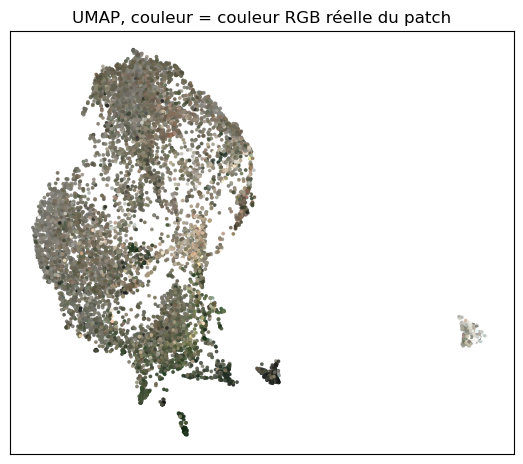

In [9]:
if UMAP_DIM!=-1:
    import umap

    t0 = time.time()
    reducer = umap.UMAP(n_components=max(2, UMAP_DIM), n_neighbors=UMAP_NEIGHBORS,
                        min_dist=UMAP_MIN_DIST, metric="cosine", random_state=0)
    u = reducer.fit_transform(z)
    print(f"UMAP {u.shape} en {time.time()-t0:.0f}s "
          f"(n_neighbors={UMAP_NEIGHBORS}, min_dist={UMAP_MIN_DIST})")
    
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(u[:, 0], u[:, 1],
               c=np.clip(px / max(np.nanpercentile(px, 98), 1e-6), 0, 1), s=3, alpha=0.8)
    ax.set_title("UMAP, couleur = couleur RGB réelle du patch")
    ax.set_xticks([]); ax.set_yticks([]); plt.show()
else:
    u=z

Ce tracé, coloré par la couleur réelle, se lit avant tout k-means : si les
paquets séparés par UMAP correspondent à des couleurs franchement différentes,
DINOv3 n'encode guère plus que la radiométrie ; s'ils mélangent des couleurs
proches, c'est qu'il sépare des **textures**, et c'est là que la méthode
apporte quelque chose.

## 8. k-means sur l'UMAP — **la cellule à rejouer pour régler `K`**

Rien de coûteux ici. On peut relancer autant de fois qu'on veut en changeant `K`.

`ALGO = "hdbscan"` est une alternative qui **trouve le nombre de groupes toute
seule** et laisse en dehors les points ambigus (étiquette −1) : utile quand on
ne sait pas quoi mettre dans `K`.

In [10]:
from sklearn.cluster import KMeans

K    = K           # <-- à modifier et réexécuter
ALGO = "kmeans"      # "kmeans" ou "hdbscan"

if ALGO == "kmeans":
    model_c = KMeans(n_clusters=K, n_init=10, random_state=0).fit(u)
    labels = model_c.labels_
    centers = model_c.cluster_centers_
else:
    from sklearn.cluster import HDBSCAN
    model_c = HDBSCAN(min_cluster_size=max(25, u.shape[0] // 200)).fit(u)
    labels = model_c.labels_
    K = labels.max() + 1
    centers = np.stack([u[labels == k].mean(0) for k in range(K)]) if K else np.zeros((0, u.shape[1]))
    print(f"HDBSCAN a trouvé {K} groupes, {100*(labels==-1).mean():.1f}% de points non classés")

# labels < 0 (HDBSCAN) = points non classes
cmap = categorical_cmap(max(K, 1))

print(f"\n k | taille  |   R     V     B   (réflectance moyenne du groupe)")
for k in range(K):
    m = labels == k
    r, g, b = np.nanmean(px[m], axis=0)
    print(f"{k:2d} | {m.sum():6d}  | {r:.3f} {g:.3f} {b:.3f}")

try:
    from sklearn.metrics import silhouette_score
    sub = np.random.default_rng(0).choice(u.shape[0], size=min(5000, u.shape[0]), replace=False)
    ok = labels[sub] >= 0
    print(f"\nsilhouette dans l'espace UMAP (échantillon) : "
          f"{silhouette_score(u[sub][ok], labels[sub][ok]):.3f}")
except Exception as e:
    print("silhouette non calculée :", e)


 k | taille  |   R     V     B   (réflectance moyenne du groupe)
 0 |    726  | 0.092 0.093 0.080
 1 |    782  | 0.104 0.100 0.087
 2 |    481  | 0.213 0.214 0.209
 3 |    203  | 0.041 0.054 0.035
 4 |    702  | 0.122 0.119 0.104
 5 |    361  | 0.113 0.108 0.094
 6 |    540  | 0.109 0.104 0.092
 7 |    731  | 0.095 0.096 0.077
 8 |    261  | 0.045 0.046 0.041
 9 |    406  | 0.105 0.102 0.089
10 |    855  | 0.099 0.097 0.085
11 |    604  | 0.098 0.095 0.080
12 |    764  | 0.106 0.103 0.093
13 |    373  | 0.065 0.072 0.057
14 |    898  | 0.105 0.101 0.090
15 |    257  | 0.107 0.100 0.085
16 |    869  | 0.085 0.088 0.070
17 |    542  | 0.131 0.123 0.104
18 |    660  | 0.103 0.101 0.090
19 |    441  | 0.108 0.101 0.088

silhouette dans l'espace UMAP (échantillon) : 0.434


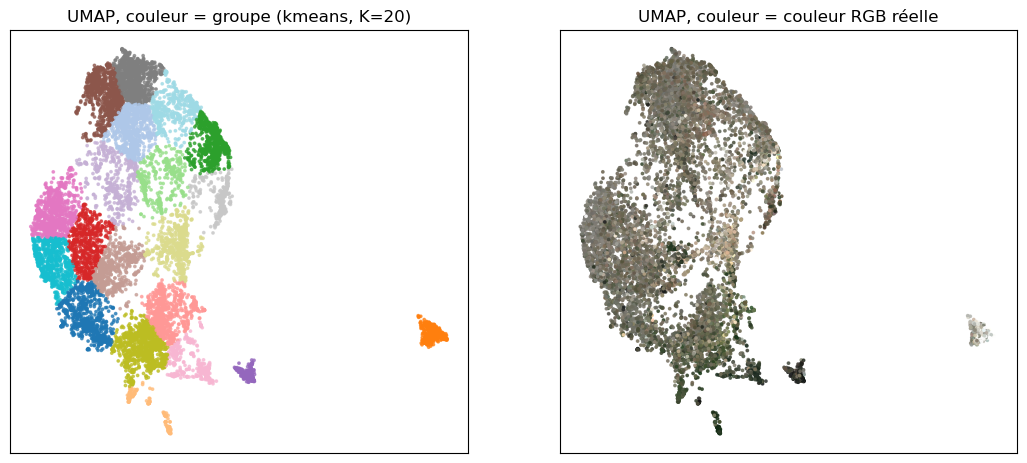

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(u[:, 0], u[:, 1], c=np.where(labels < 0, K, labels), cmap=cmap,
                s=3, alpha=0.7, vmin=-0.5, vmax=max(K, 1) - 0.5)
axes[0].set_title(f"UMAP, couleur = groupe ({ALGO}, K={K})")
axes[1].scatter(u[:, 0], u[:, 1],
                c=np.clip(px / max(np.nanpercentile(px, 98), 1e-6), 0, 1), s=3, alpha=0.8)
axes[1].set_title("UMAP, couleur = couleur RGB réelle")
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.show()

## 9. Les groupes replacés sur les tuiles

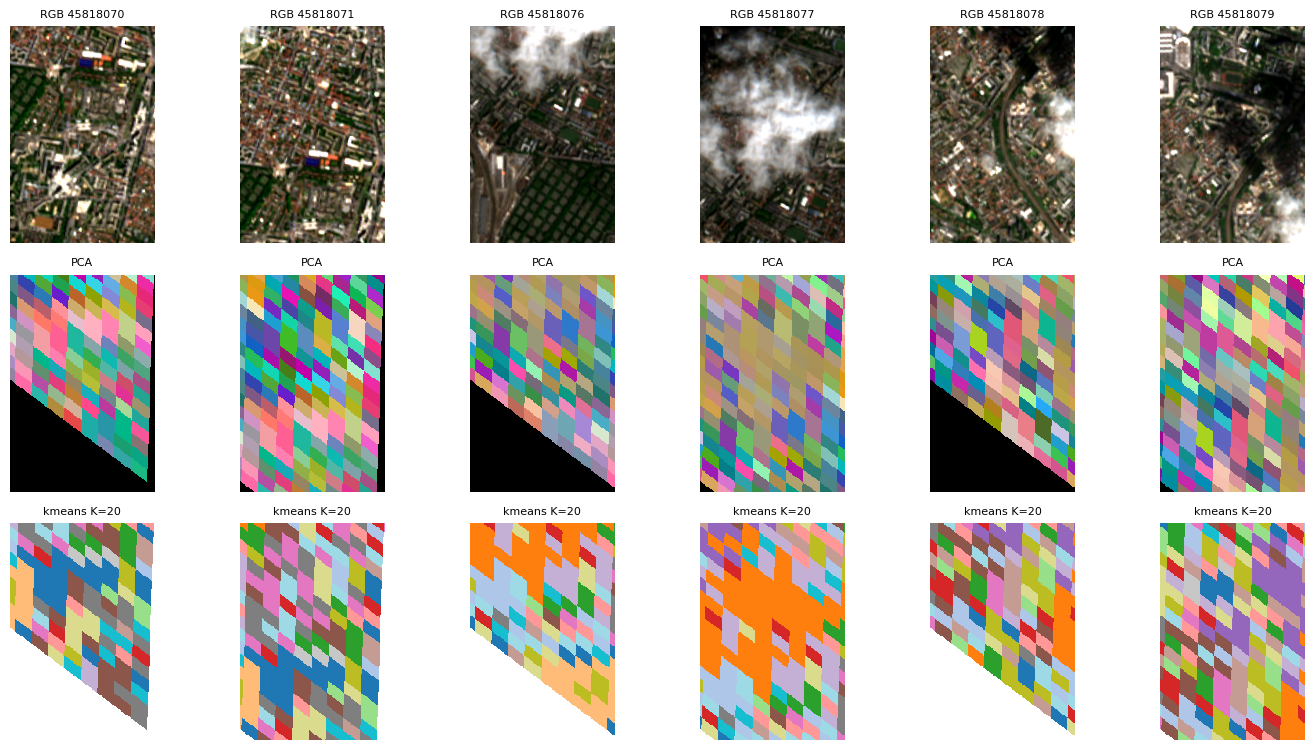

In [12]:
n = min(6, res.cell_id.size)
fig, axes = plt.subplots(3, n, figsize=(2.4 * n, 7.6), squeeze=False)
for j in range(n):
    axes[0, j].imshow(to_rgb(kept_tiles[j])); axes[0, j].set_title(f"RGB {res.cell_id[j]}", fontsize=8)
    axes[1, j].imshow(np.nan_to_num(raster(proj_n, j)), interpolation="nearest")
    axes[1, j].set_title("PCA", fontsize=8)
    axes[2, j].imshow(raster(np.where(labels < 0, np.nan, labels), j)[..., 0],
                      cmap=cmap, vmin=-0.5, vmax=max(K, 1) - 0.5, interpolation="nearest")
    axes[2, j].set_title(f"{ALGO} K={K}", fontsize=8)
    for a in axes[:, j]:
        a.set_axis_off()
fig.tight_layout(); plt.show()

Comment lire ces trois lignes :

- si **PCA** montre les structures mais que les groupes les hachent, `K` est trop
  grand, ou `UMAP_NEIGHBORS` trop petit (UMAP a fragmenté la variété) ;
- si des objets visiblement différents tombent dans le même groupe, `K` est trop
  petit, ou `UMAP_NEIGHBORS` trop grand ;
- si les groupes suivent un dégradé de luminosité plutôt que les objets, les
  embeddings sont dominés par l'éclairement : voir §11.

### 9b. À quoi ressemble un groupe donné ?

Extrait les patches de 16 px les plus proches du centre du groupe, dans l'espace
UMAP.

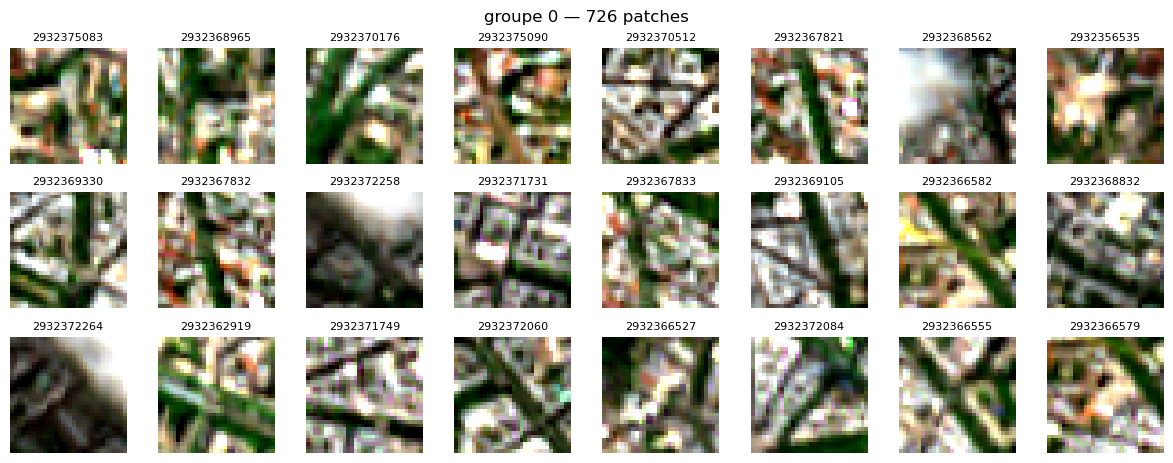

In [13]:
CLUSTER = 0     # <-- groupe à inspecter

d = np.linalg.norm(u - centers[CLUSTER], axis=1)
d[labels != CLUSTER] = np.inf
best = np.argsort(d)[:24]

# une petite fenetre tangente autour de chaque cellule retenue : c'est ce que
# le reseau voit autour d'elle, dans les trois projections
from healpix_analyse.dino import sample_healpix, tangent_grid_lonlat, healpix_gsd_m
_gsd = healpix_gsd_m(level) if GSD_M is None else GSD_M
_lo, _la = cell_centres_lonlat(res.patch_level, res.patch_cell_id[best])
_win = 32
_glon, _glat = tangent_grid_lonlat(_lo, _la, _win, _gsd / 6371000.0)
_v, _ = sample_healpix(rgb, cell_id, level, _glon, _glat)
patches = [to_rgb(np.transpose(_v[i], (2, 0, 1)), 5, 95) for i in range(len(best))]
show_tiles(patches, [f"{res.patch_cell_id[b]}" for b in best], ncol=8, size=1.5)
plt.suptitle(f"groupe {CLUSTER} — {(labels == CLUSTER).sum()} patches", y=1.02)
plt.show()

## 10. Carte HEALPix des groupes

Avec `healpix_plot`, en lon/lat. Les patches sont au niveau `res.patch_level`.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.384185791015625].


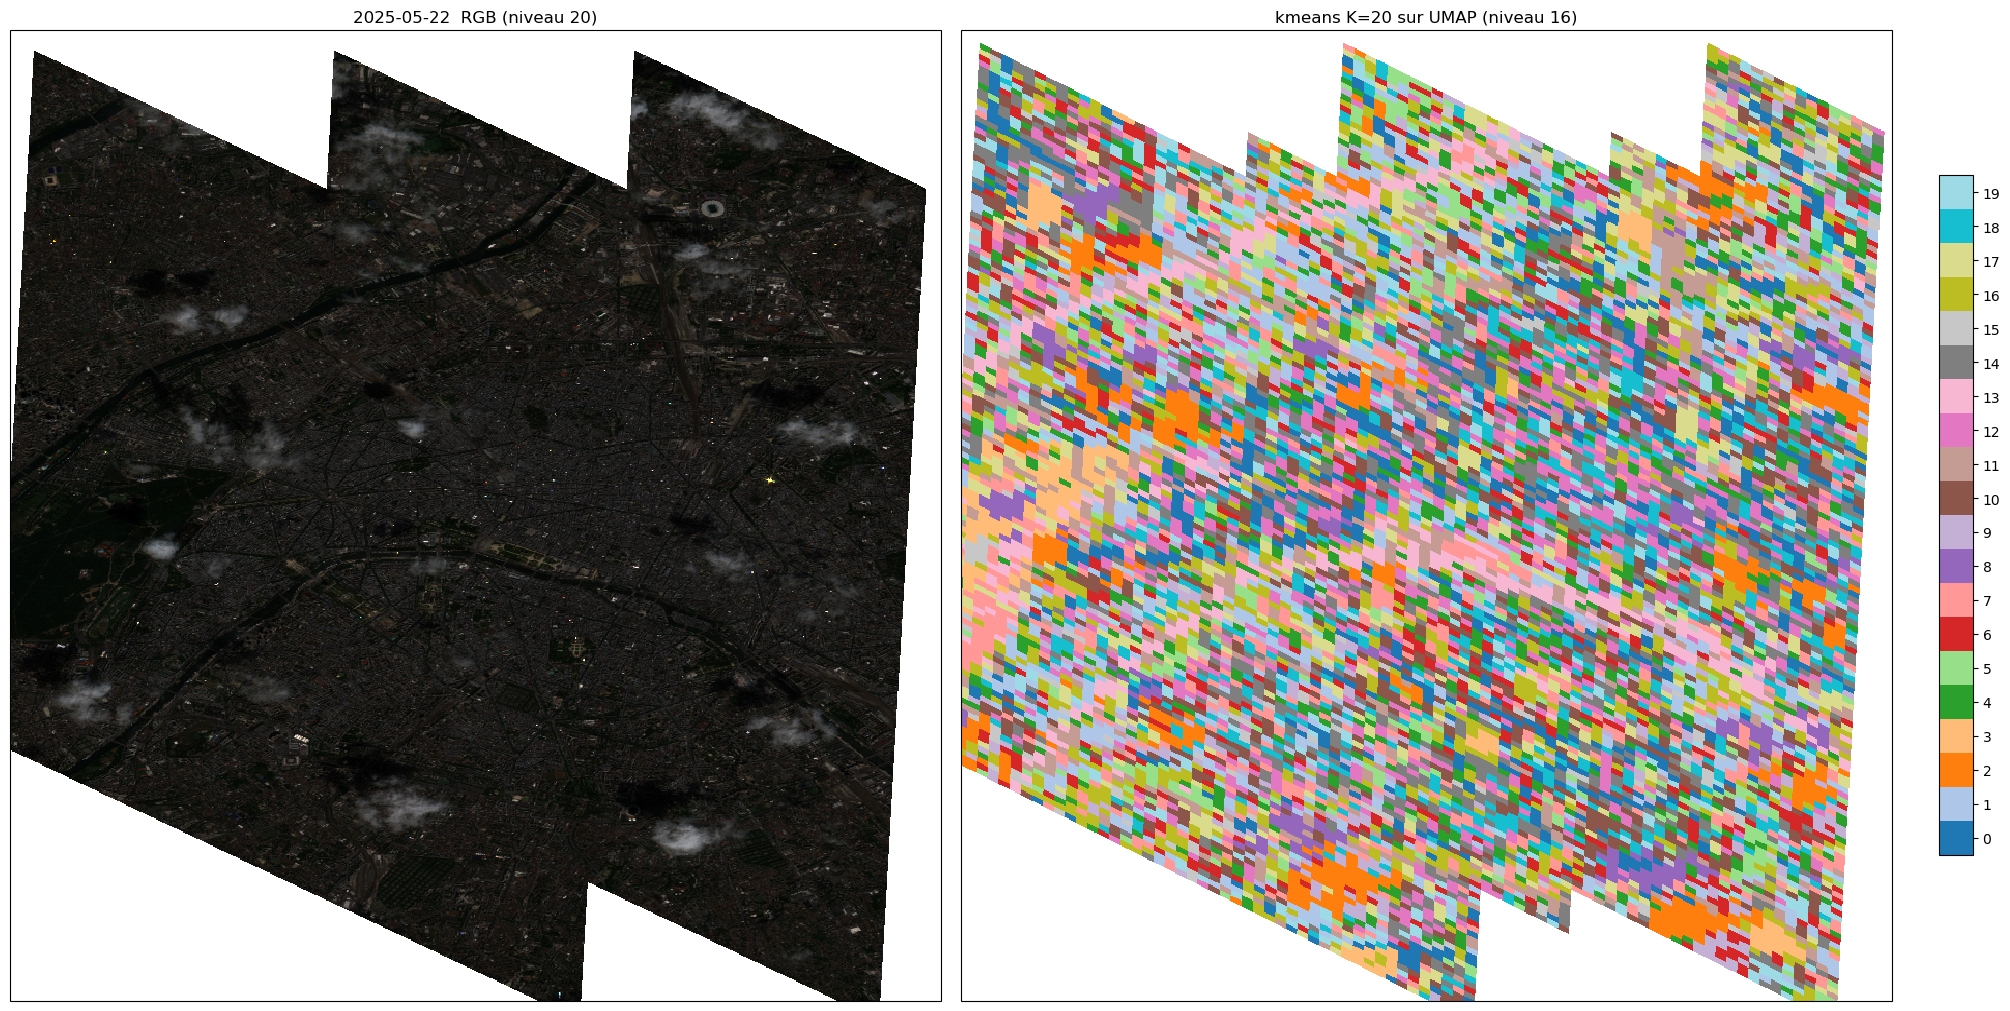

In [14]:
import cartopy.crs as ccrs
import healpix_plot

grid_px    = healpix_plot.HealpixGrid(level=level, indexing_scheme="nested", ellipsoid="WGS84")
grid_patch = healpix_plot.HealpixGrid(level=res.patch_level, indexing_scheme="nested",
                                      ellipsoid="WGS84")

fig, axes = plt.subplots(1, 2, figsize=(20, 10),
                         subplot_kw={"projection": ccrs.PlateCarree()}, layout="constrained")
hi = np.nanpercentile(rgb, 98)
healpix_plot.plot(cell_id, rgb, healpix_grid=grid_px, sampling_grid={"shape": 900},
                  ax=axes[0], rgb_clip=(0.0, float(hi)), axis_labels="none",
                  title=f"{dates[TIME_INDEX]}  RGB (niveau {level})")
mp = healpix_plot.plot(res.patch_cell_id, np.where(labels < 0, np.nan, labels).astype(np.float32),
                       healpix_grid=grid_patch, sampling_grid={"shape": 900},
                       ax=axes[1], cmap=cmap, vmin=-0.5, vmax=max(K, 1) - 0.5,
                       axis_labels="none",
                       title=f"{ALGO} K={K} sur UMAP (niveau {res.patch_level})")
fig.colorbar(mp, ax=axes[1], shrink=0.7, ticks=range(K))
plt.show()

## 11. Cohérence spatiale des groupes

Un indicateur simple et parlant : la fraction de patches voisins (dans la même
tuile) qui portent la même étiquette. Une classification qui a du sens
géographique est nettement au-dessus du hasard (`1/K`).

In [15]:
# voisinage HEALPix reel, pas la grille de l'image : valable aussi bien en mode
# tuile qu'en percell, et les frontieres de tuiles ne faussent plus le compte
order = np.argsort(res.patch_cell_id)
sid = res.patch_cell_id[order]
slab = labels[order]
nb = cell_neighbours(res.patch_level, sid)                            # [8, N]
pos = np.clip(np.searchsorted(sid, nb), 0, sid.size - 1)
ok = (nb >= 0) & (sid[pos] == nb)
same = (slab[pos] == slab[None, :]) & ok
print(f"voisins de même étiquette : {same.sum()/ok.sum():.3f}   (hasard : {1/max(K,1):.3f})")

voisins de même étiquette : 0.191   (hasard : 0.050)


## 12. Trois espaces de classification comparés

La même méthode k-means appliquée à trois représentations : les coordonnées
UMAP, les embeddings DINOv3 bruts, et la couleur moyenne seule. L'indice de Rand
ajusté chiffre à quel point deux partitions se recoupent (1 = identiques,
0 = sans rapport).

Lecture utile : si **UMAP** et **couleur seule** donnent la même chose,
l'embedding n'apporte pas de texture. Si **UMAP** et **DINO brut** diffèrent
beaucoup, c'est UMAP qui fabrique la structure — ce n'est pas rédhibitoire, mais
les groupes dépendent alors de ses réglages, à vérifier en changeant la graine.

UMAP  vs  DINO brut       : 0.375
UMAP  vs  couleur seule   : 0.025
DINO  vs  couleur seule   : 0.021


/srv/conda/envs/notebook/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP graine 0  vs  graine 1 : 0.735  (proche de 1 = partition stable)


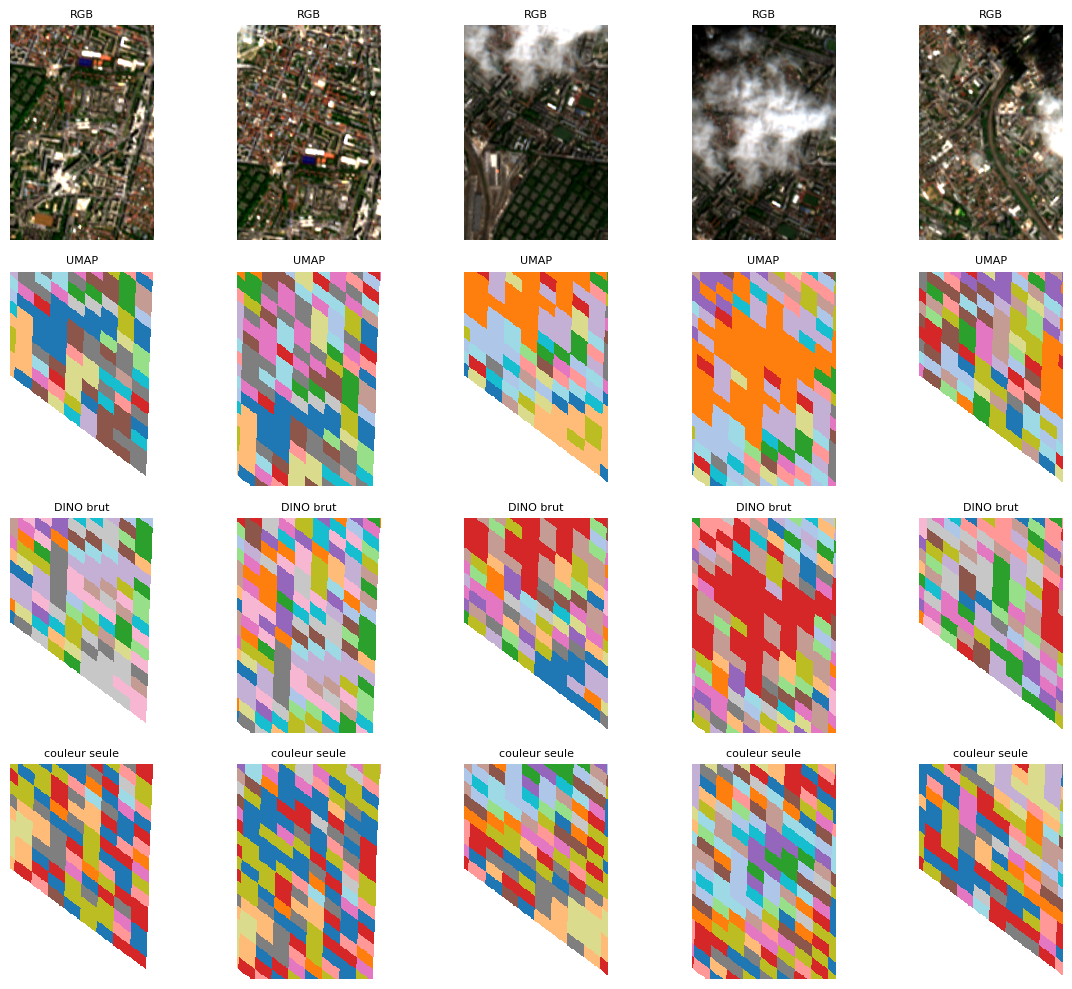

In [16]:
from sklearn.metrics import adjusted_rand_score

lab_dino = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(z)
lab_rgb  = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(np.nan_to_num(px))

print(f"UMAP  vs  DINO brut       : {adjusted_rand_score(labels, lab_dino):.3f}")
print(f"UMAP  vs  couleur seule   : {adjusted_rand_score(labels, lab_rgb):.3f}")
print(f"DINO  vs  couleur seule   : {adjusted_rand_score(lab_dino, lab_rgb):.3f}")

# stabilité de la partition UMAP à une autre graine
u2 = umap.UMAP(n_components=max(2, UMAP_DIM), n_neighbors=UMAP_NEIGHBORS,
               min_dist=UMAP_MIN_DIST, metric="cosine", random_state=1).fit_transform(z)
lab_u2 = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(u2)
print(f"UMAP graine 0  vs  graine 1 : {adjusted_rand_score(labels, lab_u2):.3f}  "
      "(proche de 1 = partition stable)")

n = min(5, res.cell_id.size)
fig, axes = plt.subplots(4, n, figsize=(2.4 * n, 10), squeeze=False)
rows = [("RGB", None), ("UMAP", labels), ("DINO brut", lab_dino),
        ("couleur seule", lab_rgb)]
for j in range(n):
    for i, (name, arr) in enumerate(rows):
        if arr is None:
            axes[i, j].imshow(to_rgb(kept_tiles[j]))
        else:
            axes[i, j].imshow(raster(arr.astype(float), j)[..., 0], cmap=cmap,
                              vmin=-0.5, vmax=max(K, 1) - 0.5, interpolation="nearest")
        axes[i, j].set_title(name, fontsize=8); axes[i, j].set_axis_off()
fig.tight_layout(); plt.show()

## 13. Aide-mémoire de réglage

| symptôme | paramètre | où reprendre |
|---|---|---|
| **cercles ovalisés, objets penchés de 45°** | `PROJECTION = "tangent"` | §3 |
| il faut un embedding exactement centré sur chaque cellule | `PROJECTION = "percell"` (une passe par cellule, très coûteux ; `TILE_LEVELS` fixe alors le niveau de sortie) | §1 puis §4 |
| **le contour des tuiles est visible sur la carte** | `TOKEN_NORM = "tile"`, `TILE_LEVELS` plus grand, date moins voilée | §5 (ou §3) |
| trop peu de groupes, tout est mélangé | `K` | §8 seulement |
| on ne sait pas quoi mettre dans `K` | `ALGO = "hdbscan"` | §8 seulement |
| groupes hachés, sans cohérence spatiale (§11 proche de 1/K) | `UMAP_NEIGHBORS` plus grand | §7 |
| un seul gros paquet dans l'UMAP | `UMAP_NEIGHBORS` plus petit, `UMAP_MIN_DIST = 0.0` | §7 |
| partition instable d'une graine à l'autre (§12) | `UMAP_DIM` 5–10, ou classer sur DINO brut | §7 |
| tuiles trop petites, pas de contexte | `TILE_LEVELS` (8 → 256 px, 10 → 1024 px) | §3 |
| presque aucune tuile gardée | `MIN_COVERAGE` (0.95 tolère quelques nuages) | §3 |
| carte bruitée alors que la PCA (§6) est déjà du bruit | rien à régler ici | le problème est les embeddings |
| résultat identique à la couleur (§12) | `TILE_LEVELS` plus grand, vérifier la normalisation SAT | §3 |

Deux constantes valent la peine d'être vérifiées contre le *model card* de la
version des poids téléchargée : `SAT493M_MEAN` et `SAT493M_STD` dans
`healpix_analyse/dino.py`. Une normalisation fausse dégrade les features sans
produire d'erreur visible.

Une fois les réglages trouvés, on passe aux 88 dates :

```bash
python dino_umap_sentinel2.py --weights ... --cache ~/s2_cache \
    --clusters K --tile-levels 8 --umap-neighbors 30 --umap-min-dist 0.0
```

(le script classe lui aussi sur l'UMAP par défaut ; `--cluster-space dino` pour
revenir aux embeddings bruts).